In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings


#-----------------------------------------------------------
#---------------Data Loading & Preprocessing----------------
#-----------------------------------------------------------

df = pd.read_csv('preprocessed.csv')
print("Hoan thanh load data. Shape:", df.shape)
print("Cac cot trong data:", df.columns.tolist())

# Tao ban sao de thuc hien lam sach tung buoc
df_cp = df.copy()

Hoan thanh load data. Shape: (9993, 10)
Cac cot trong data: ['movie_sk', 'title', 'genre', 'director', 'average_rating', 'weighted_rating', 'num_votes', 'log_votes', 'rating_diff', 'popularity_level']


In [3]:
#----------------------------------------------------------
#---------------Detecting Dataset Biases-------------------
#----------------------------------------------------------

def detect_movie_dataset_bias(df):
    print("-" * 60)
    print("MOVIE DATASET BIAS DETECTOR")
    print("-" * 60)
    
    #Lay Primary Gener de tu cot genre (Neu co nhieu the loai thi lay the loai dau tien lam chinh)
    df['Primary_Genre'] = df['genre'].apply(lambda x: str(x).split(',')[0].strip().title())
    
    #Lay top 8 the loai pho bien nhat de bieu do khong bi roi (Noise reduction)
    top_genres = df['Primary_Genre'].value_counts().head(8).index
    df_top = df[df['Primary_Genre'].isin(top_genres)].copy()

    #Tao figure co 3 subplots de hien thi 3 loai bias
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.set_theme(style="whitegrid")
    
    #---------------------------------------------------------
    #1. Class Imbalance Bias 
    #---------------------------------------------------------
    genre_counts = df_top['Primary_Genre'].value_counts()
    
    sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=axes[0], palette="viridis")
    axes[0].set_title("1. Sai lech phan phoi The loai", fontweight='bold')
    axes[0].set_ylabel("So luong phim")
    axes[0].tick_params(axis='x', rotation=45)
    
    print("\n[1] SAI LECH PHAN PHOI (Class Imbalance):")
    print(genre_counts.to_string())
    ratio = genre_counts.max() / genre_counts.min()
    print(f"==> Lop nhieu nhat gap {ratio:.1f} lan lop it nhat.")
    if ratio > 5:
        print("!!! Du lieu bi lech nang. Mo hinh se co xu huong bias lop da so.")
    else:
        print("Du lieu kha can bang.")

    #---------------------------------------------------------
    #2. Interaction Bias 
    #---------------------------------------------------------
    sns.boxplot(data=df_top, x='Primary_Genre', y='log_votes', ax=axes[1], palette="Set2", order=top_genres)
    axes[1].set_title("2. Sai lech Luot Tuong tac (Log_Votes)", fontweight='bold')
    axes[1].set_ylabel("Log_Votes")
    axes[1].tick_params(axis='x', rotation=45)
    
    print("\n[2] SAI LECH TUONG TAC (Interaction Bias):")
    votes_stats = df_top.groupby('Primary_Genre')['log_votes'].mean().round(2).sort_values(ascending=False)
    print("Log_votes trung binh theo tung The loai:")
    print(votes_stats.to_string())
    
    #---------------------------------------------------------
    #3. Sparse Metadata Bias 
    #---------------------------------------------------------
    
    #Dem so lan xuat hien cua tung dao dien 
    director_counts = df['director'].value_counts()

    #Gan 1 neu dao dien chi xuat hien 1 lan, nguoc lai gan 0
    df_top['is_sparse_director'] = df_top['director'].apply(lambda x: 1 if director_counts.get(x, 0) == 1 else 0)
    
    sparse_ratio = (df_top.groupby('Primary_Genre')['is_sparse_director'].mean() * 100).round(1).sort_values(ascending=False)
    
    sns.barplot(x=sparse_ratio.index, y=sparse_ratio.values, ax=axes[2], palette="magma")
    axes[2].set_title("3. Ti le dao dien 'Vo danh' (%)", fontweight='bold')
    axes[2].set_ylabel("%Dao dien chi lam 1 phim")
    axes[2].tick_params(axis='x', rotation=45)
    
    print("\n[3] SAI LECH THONG TIN THUC THE (Sparse Metadata Bias):")
    print("Ti le phim co dao dien chi xuat hien 1 lan:")
    for k, v in sparse_ratio.items():
        print(f" - {k}: {v:.1f}%")
        
    diff = sparse_ratio.max() - sparse_ratio.min()
    if diff > 15:
        print(f"==> Muc do ngheo nan thong tin chenh lech toi {diff:.1f}%.")
        print("!!! Cac the loai ty le cao se cuc ky kho tim ra diem chung (Cross-recommendation) qua cot Dau dien.")
        
    plt.tight_layout()
    plt.show()

------------------------------------------------------------
MOVIE DATASET BIAS DETECTOR
------------------------------------------------------------


C:\Users\Bao Khang\AppData\Local\Temp\ipykernel_12204\1041151840.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=axes[0], palette="viridis")
C:\Users\Bao Khang\AppData\Local\Temp\ipykernel_12204\1041151840.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='Primary_Genre', y='log_votes', ax=axes[1], palette="Set2", order=top_genres)



[1] SAI LECH PHAN PHOI (Class Imbalance):
Primary_Genre
Drama        2112
Comedy       1952
Action       1309
Horror        934
Animation     536
Adventure     517
Thriller      514
Crime         455
==> Lop nhieu nhat gap 4.6 lan lop it nhat.
Du lieu kha can bang.

[2] SAI LECH TUONG TAC (Interaction Bias):
Log_votes trung binh theo tung The loai:
Primary_Genre
Adventure    3.30
Action       3.20
Animation    3.09
Crime        3.07
Horror       3.05
Drama        3.02
Thriller     3.02
Comedy       2.99


C:\Users\Bao Khang\AppData\Local\Temp\ipykernel_12204\1041151840.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sparse_ratio.index, y=sparse_ratio.values, ax=axes[2], palette="magma")



[3] SAI LECH THONG TIN THUC THE (Sparse Metadata Bias):
Ti le phim co dao dien chi xuat hien 1 lan:
 - Animation: 52.1%
 - Horror: 30.1%
 - Thriller: 26.5%
 - Comedy: 24.4%
 - Drama: 21.8%
 - Adventure: 21.5%
 - Action: 18.0%
 - Crime: 15.8%
==> Muc do ngheo nan thong tin chenh lech toi 36.3%.
!!! Cac the loai ty le cao se cuc ky kho tim ra diem chung (Cross-recommendation) qua cot Dau dien.


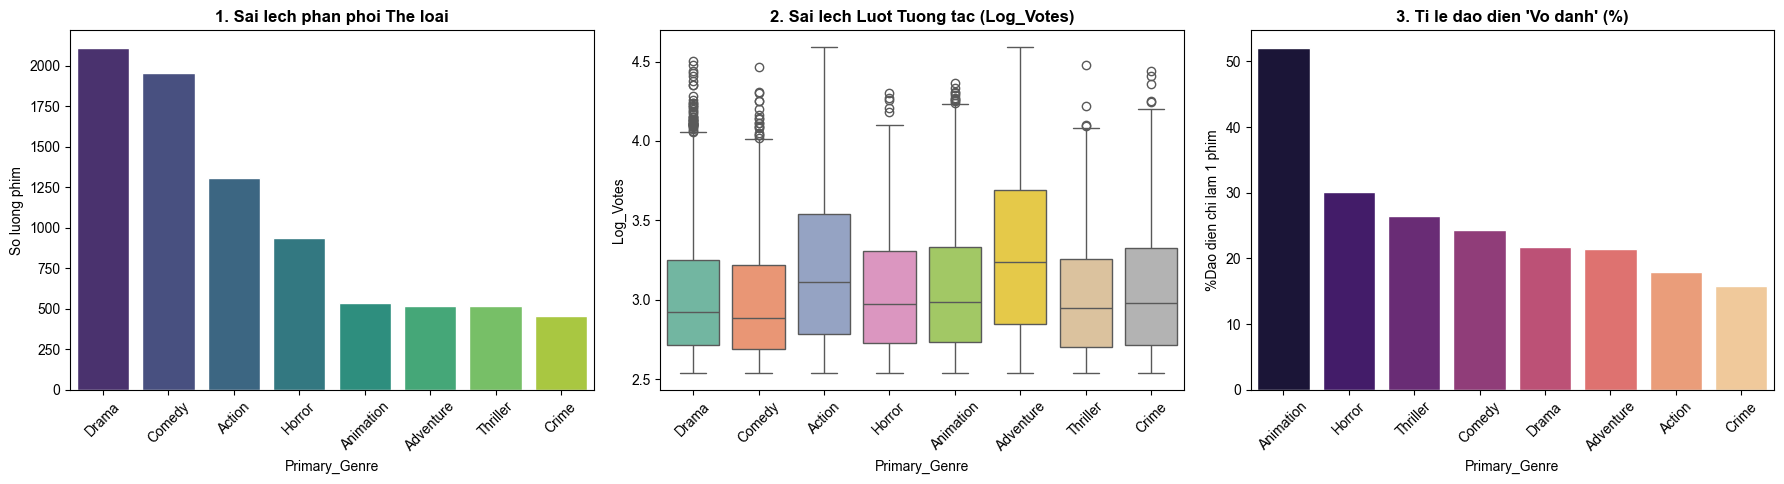

In [4]:
detect_movie_dataset_bias(df)

#### 1. Phân tích Đơn biến: Lượt tương tác (num_votes & log_votes)

   *Vấn đề:* Trong dữ liệu điện ảnh, lượt vote tuân theo định luật Pareto (Phân phối Right-skewed - lệch phải nhiều). Việc sử dụng các phương pháp như Min-Max Scaler sẽ bị vô hiệu hóa vì có các phim "bom tấn" có hàng triệu lượt vote sẽ bóp nghẹt các phim bình thường về sát 0. Tương tự, Z-score cũng không phù hợp vì giá trị Trung bình (Mean) và Độ lệch chuẩn (Standard Deviation) bị kéo lệch quá mạnh, dẫn đến đánh giá sai ngưỡng cắt. 
   
   *Giải pháp (Log + IQR):* Sử dụng phép biến đổi Logarit (log_votes) để thu hẹp khoảng cách giữa các giá trị cực đoan, đưa dữ liệu về trạng thái gần với Phân phối chuẩn (Normal Distribution) nhất.  Áp dụng phương pháp IQR (Interquartile Range) trên tập Log này. Vì IQR dựa trên Trung vị (Median) và Tứ phân vị (Q1 & Q3) nên sẽ giúp xác định ngưỡng cắt chính xác và ổn định hơn Z-score.

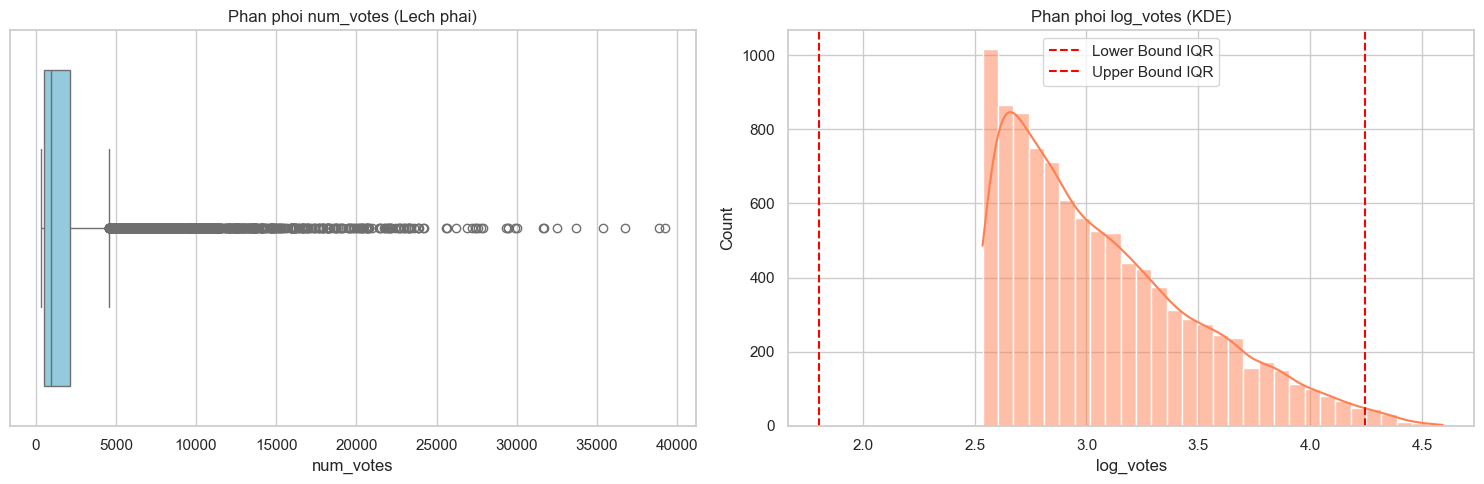

Nguong cat duoi (Lower Bound): 1.81
Nguong cat tren (Upper Bound): 4.25


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Boxplot cho num_votes
sns.boxplot(x=df_cp['num_votes'], ax=axes[0], color='skyblue')
axes[0].set_title('Phan phoi num_votes (Lech phai)')

#Histogram cho log_votes
sns.histplot(df_cp['log_votes'], kde=True, ax=axes[1], color='coral', bins=30)
axes[1].set_title('Phan phoi log_votes (KDE)')

#Tinh toan nguong IQR
Q1 = df_cp['log_votes'].quantile(0.25)
Q3 = df_cp['log_votes'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

axes[1].axvline(lower_bound, color='red', linestyle='--', label='Lower Bound IQR')
axes[1].axvline(upper_bound, color='red', linestyle='--', label='Upper Bound IQR')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Nguong cat duoi (Lower Bound): {lower_bound:.2f}")
print(f"Nguong cat tren (Upper Bound): {upper_bound:.2f}")

In [6]:
#Loc bo cac phim nam ngoai nguong IQR
mask_log = (df_cp['log_votes'] >= lower_bound) & (df_cp['log_votes'] <= upper_bound)
df_cp = df_cp[mask_log]

print(f"So luong phim con lai sau khi xu ly log_votes: {df_cp.shape[0]}")

So luong phim con lai sau khi xu ly log_votes: 9888


#### 2. Phân tích Đơn biến: Độ lệch điểm (rating_diff)
  
  *Vấn đề:* rating_diff là một thuộc tính đo lường sự chênh lệch giữa điểm trung bình cộng và điểm trọng số (Bayesian Rating), phản ánh tính logic của dữ liệu.

  *Giải pháp:* dùng Hard Threshold [-2, 2] vì nếu áp dụng IQR hay Z-score cho rating_diff, chúng ta sẽ hoàn toàn phụ thuộc vào hình dáng phân phối, nhưng trong trường hợp dữ liệu chứa quá nhiều phim bị Review Bombing, các phương pháp thống kê sẽ tự nới rộng ngưỡng chấp nhận, vô tình giữ lại các phim có sai số điểm lên đến 4-5 điểm --> sử dụng Domain Knowledge để áp đặt ngưỡng chặn cứng tại [-2, 2]. Một bộ phim chênh lệch quá 2 điểm giữa hai thuật toán là minh chứng cho sự mâu thuẫn dữ liệu nghiêm trọng (Data Inconsistency).

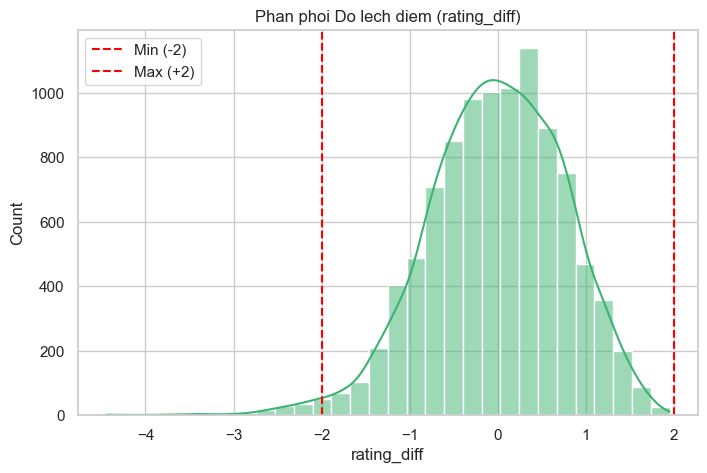

Phat hien 118 phim co do lech diem vuot qua khoang [-2, 2]


In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df_cp['rating_diff'], kde=True, color='mediumseagreen', bins=30)
plt.axvline(-2, color='red', linestyle='--', label='Min (-2)')
plt.axvline(2, color='red', linestyle='--', label='Max (+2)')
plt.title('Phan phoi Do lech diem (rating_diff)')
plt.legend()
plt.show()

outliers_diff = df_cp[(df_cp['rating_diff'] < -2) | (df_cp['rating_diff'] > 2)].shape[0]
print(f"Phat hien {outliers_diff} phim co do lech diem vuot qua khoang [-2, 2]")

In [8]:
#Giu lai cac phim co do lech diem tu -2 den +2
mask_diff = (df_cp['rating_diff'] >= -2) & (df_cp['rating_diff'] <= 2)
df_cp = df_cp[mask_diff]

print(f"So luong phim con lai sau khi xu ly rating_diff: {df_cp.shape[0]}")

So luong phim con lai sau khi xu ly rating_diff: 9770


#### 3. Làm sạch chất lượng văn bản (director)
   
   *Vấn đề:* Quá trình Web Scraping thường phát sinh lỗi mã hóa Mojibake (vd: beyoncÃ©). Các thư viện NLP như NLTK hay SpaCy thường chỉ tập trung vào tách từ (Tokenization). Nếu giao phó hoàn toàn, từ beyoncÃ© có thể bị tách thành các phần vô nghĩa hoặc bị xóa bỏ.

   *Giải pháp:* Xây dựng hàm Regular Expression (Regex) để chủ động ánh xạ lại các bảng mã lỗi. Phương pháp này đảm bảo các thực thể định danh (Named Entities) không bị thất thoát hoặc biến dạng trước khi đưa vào mô hình Vectorization.


In [9]:
#Kiem tra thu cong cac ten dao dien co chua ky tu dac biet
suspicious_directors = df_cp[df_cp['director'].str.contains(r'[^\x00-\x7F]', na=False)]
print("Mot so dao dien bi loi hien thi (Mojibake):")
print(suspicious_directors['director'].head().to_string())

Mot so dao dien bi loi hien thi (Mojibake):
0             beyoncé
11        gérard oury
15       michał gazda
33    cédric klapisch
53    victor sjöström


In [10]:
def fix_encoding(text):
    if pd.isna(text): 
        return ""
    text = str(text).lower()
    # Sua cac loi co ban
    mapping = {'ã©': 'e', 'ã¢': 'a', 'ã-': 'i', 'beyoncã©': 'beyonce'}
    for k, v in mapping.items():
        text = text.replace(k, v)
    # Loai bo ky tu khong thuoc ASCII
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    return text.strip()

#Ap dung lam sach
df_cp['director'] = df_cp['director'].apply(fix_encoding)
df_cp['genre'] = df_cp['genre'].apply(fix_encoding)

print("Da chuan hoa kieu chuoi thanh cong.")

Da chuan hoa kieu chuoi thanh cong.


#### 4. Phân tích Đa biến: Contextual Outliers (Rating vs Votes)

   *Vấn đề:* Trong các hệ thống đánh giá, một điểm số cao không luôn đồng nghĩa với một bộ phim chất lượng. Có nhiều bộ phim có điểm tuyệt đối (vd: 9.0 - 10.0) nhưng chỉ dựa trên một lượng rất nhỏ lượt bình chọn (vd: < 100 votes) --> sai lệch không gian đặc trưng, khiến hệ thống ưu tiên gợi ý những phim rác hoặc phim có dữ liệu không đáng tin cậy chỉ vì chúng có điểm số cao.

   *Giải pháp:* Phân tích tương quan (Correlation Analysis): Sử dụng Scatter Plot với hai trục biến thiên là log_votes (mức độ phổ biến) và average_rating (chất lượng cảm tính). Thiết lập ngưỡng tin cậy (Confidence Threshold): Qua biểu đồ, ta xác định outlier --> quyết định loại bỏ các phim có average_rating >= 8.0 nhưng log_votes < 3.0.

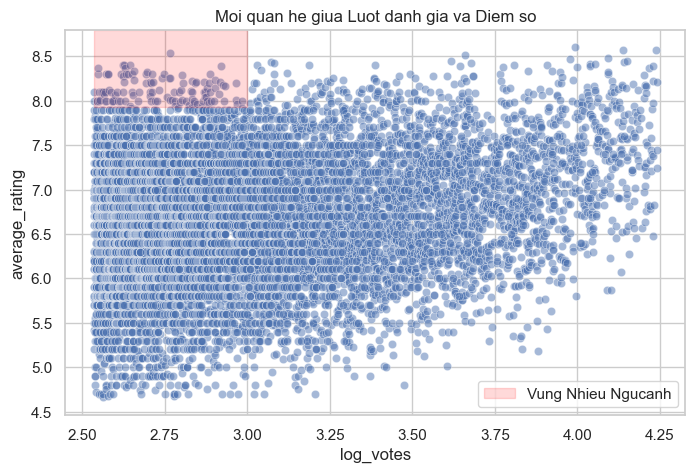

Phat hien 104 phim bi nhieu ngu canh (Ao diem).


In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_cp, x='log_votes', y='average_rating', alpha=0.5)

#Ve vung nhieu ngu canh (Rating >= 8.0 & log_votes < 3.0)
plt.axvspan(xmin=df_cp['log_votes'].min(), xmax=3.0, ymin=0.8, ymax=1.0, color='red', alpha=0.15, label='Vung Nhieu Ngucanh')
plt.title('Moi quan he giua Luot danh gia va Diem so')
plt.legend()
plt.show()

context_outliers = df_cp[(df_cp['average_rating'] >= 8.0) & (df_cp['log_votes'] < 3.0)].shape[0]
print(f"Phat hien {context_outliers} phim bi nhieu ngu canh (Ao diem).")

In [12]:
# Loai bo phim thuoc vung nhieu
mask_context = ~((df_cp['average_rating'] >= 8.0) & (df_cp['log_votes'] < 3.0))
df_cp = df_cp[mask_context]

print(f"So luong phim con lai sau khi loai ao diem: {df_cp.shape[0]}")

So luong phim con lai sau khi loai ao diem: 9666


#### 5. Phân tích Đa biến: Logic thuật toán (Average vs Weighted)

   *Vấn đề:* Khi tạo đặc trưng weighted_rating cần chú ý thuật toán tính trọng số hoặc tham số m (lượt vote tối thiểu) không được thiết lập phù hợp --> Algorithm Inconsistency — điểm trọng số bị kéo quá xa so với thực tế cảm nhận của người dùng.
   
   *Giải pháp:* Đối chiếu đường phân giác (y=x): Trực quan hóa mối quan hệ giữa average_rating và weighted_rating trên biểu đồ phân tán. Phát hiện biến dị những điểm nằm chệch hoàn toàn khỏi đường phân giác (outliers đa biến) cho thấy sự mâu thuẫn giữa điểm thô và điểm trọng số --> đảm bảo rằng weighted_rating vừa phản ánh được chất lượng phim, vừa giữ được tính logic so với đánh giá thực tế của người dùng. 

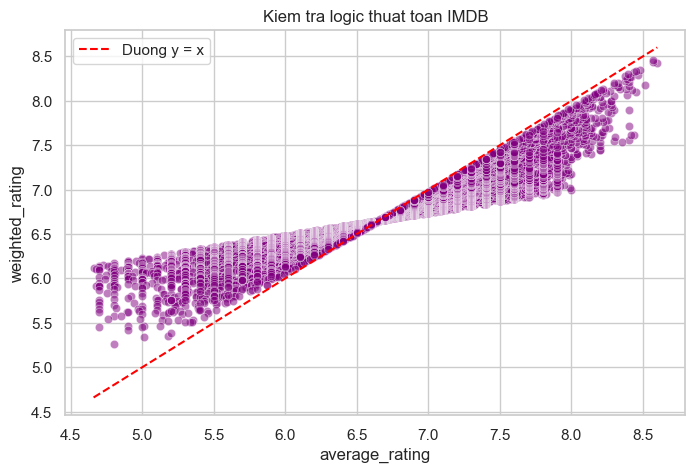

Nhan xet: Phan lon du lieu bam sat duong y=x sau khi da loc cot rating_diff.


In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_cp, x='average_rating', y='weighted_rating', alpha=0.5, color='purple')

#Ke duong thang y = x
min_val = min(df_cp['average_rating'].min(), df_cp['weighted_rating'].min())
max_val = max(df_cp['average_rating'].max(), df_cp['weighted_rating'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Duong y = x')

plt.title('Kiem tra logic thuat toan IMDB')
plt.legend()
plt.show()

print("Nhan xet: Phan lon du lieu bam sat duong y=x sau khi da loc cot rating_diff.")

#### 6. Gom nhóm đạo diễn
   
   *Vấn đề:* Có hàng ngàn đạo diễn chỉ xuất hiện duy nhất 1 lần trong tập dữ liệu. Nếu giữ nguyên --> Curse of Dimensionality, tạo ra một Ma trận thưa (Sparse Matrix) khổng lồ gây lãng phí tài nguyên tính toán và làm giảm độ chính xác khi tính Cosine Similarity (do không có điểm giao). Nếu xóa dòng --> thất thoát hàng ngàn bộ phim có nội dung (Overview) giá trị.

   *Giải pháp:* Đổi tên các đạo diễn này thành unknown_director, điều này giúp giảm hàng ngàn chiều dữ liệu thừa thãi xuống còn 1 chiều duy nhất, tối ưu hóa không gian vector nhưng vẫn giữ lại được nguyên vẹn số lượng phim cho mô hình.

C:\Users\Bao Khang\AppData\Local\Temp\ipykernel_12204\1369110551.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Dao dien 1 phim', 'Dao dien > 1 phim'],


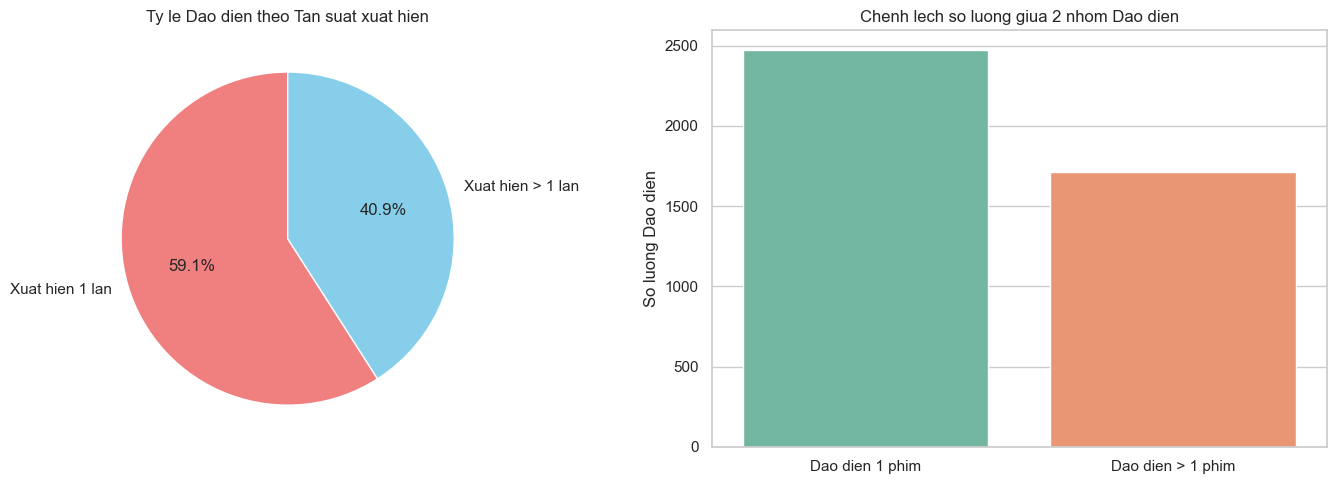

Phat hien van de: Co toi 2471 dao dien chi xuat hien duy nhat 1 lan.
Neu dua vao TF-IDF, he thong se sinh ra 2471 chieu du lieu roi rac.


In [14]:
#Tan suat xuat hien cua tung dao dien
director_counts = df_cp['director'].value_counts()
rare_directors_count = director_counts[director_counts == 1].shape[0]
popular_directors_count = director_counts[director_counts > 1].shape[0]

#Bieu do hien thi van de Sparsity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Bieu do tron: Ty le dao dien hiem
axes[0].pie([rare_directors_count, popular_directors_count], 
            labels=['Xuat hien 1 lan', 'Xuat hien > 1 lan'], 
            autopct='%1.1f%%', colors=['lightcoral', 'skyblue'], startangle=90)
axes[0].set_title('Ty le Dao dien theo Tan suat xuat hien')

#Bieu do cot: So sanh mat do
sns.barplot(x=['Dao dien 1 phim', 'Dao dien > 1 phim'], 
            y=[rare_directors_count, popular_directors_count], 
            ax=axes[1], palette='Set2')
axes[1].set_title('Chenh lech so luong giua 2 nhom Dao dien')
axes[1].set_ylabel('So luong Dao dien')

plt.tight_layout()
plt.show()

print(f"Phat hien van de: Co toi {rare_directors_count} dao dien chi xuat hien duy nhat 1 lan.")
print(f"Neu dua vao TF-IDF, he thong se sinh ra {rare_directors_count} chieu du lieu roi rac.")

In [15]:
#Ghi nhan so luong chieu du lieu ban dau
original_dim = len(director_counts)

#Xac dinh danh sach cac dao dien chi xuat hien 1 lan
rare_directors_list = director_counts[director_counts == 1].index

#Thay the ten dao dien hiem bang nhan chung 'unknown_director'
df_cp['director'] = df_cp['director'].apply(lambda x: 'unknown_director' if x in rare_directors_list else x)

#Tinh toan lai so chieu du lieu sau khi gom nhom
new_dim = df_cp['director'].nunique()
dim_reduced = original_dim - new_dim

print("-"*60)
print("BAO CAO TOI UU HOA KHONG GIAN VECTOR (DIMENSIONALITY REDUCTION)")
print("-"*60)
print(f"So luong chieu du lieu (Dao dien) ban dau : {original_dim}")
print(f"So luong chieu du lieu sau khi gom nhom   : {new_dim}")
print(f"So chieu du lieu thua thai da loai bo    : {dim_reduced}")
print("\n==> Ma tran TF-IDF se nhe hon rat nhieu va chay nhanh hon ma khong he mat di bat ky bo phim nao.")

------------------------------------------------------------
BAO CAO TOI UU HOA KHONG GIAN VECTOR (DIMENSIONALITY REDUCTION)
------------------------------------------------------------
So luong chieu du lieu (Dao dien) ban dau : 4183
So luong chieu du lieu sau khi gom nhom   : 1713
So chieu du lieu thua thai da loai bo    : 2470

==> Ma tran TF-IDF se nhe hon rat nhieu va chay nhanh hon ma khong he mat di bat ky bo phim nao.


------------------------------------------------------------
FINAL VISUAL QA
------------------------------------------------------------


C:\Users\Bao Khang\AppData\Local\Temp\ipykernel_12204\3491237419.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, ax=axes[1, 2], palette='Set2')


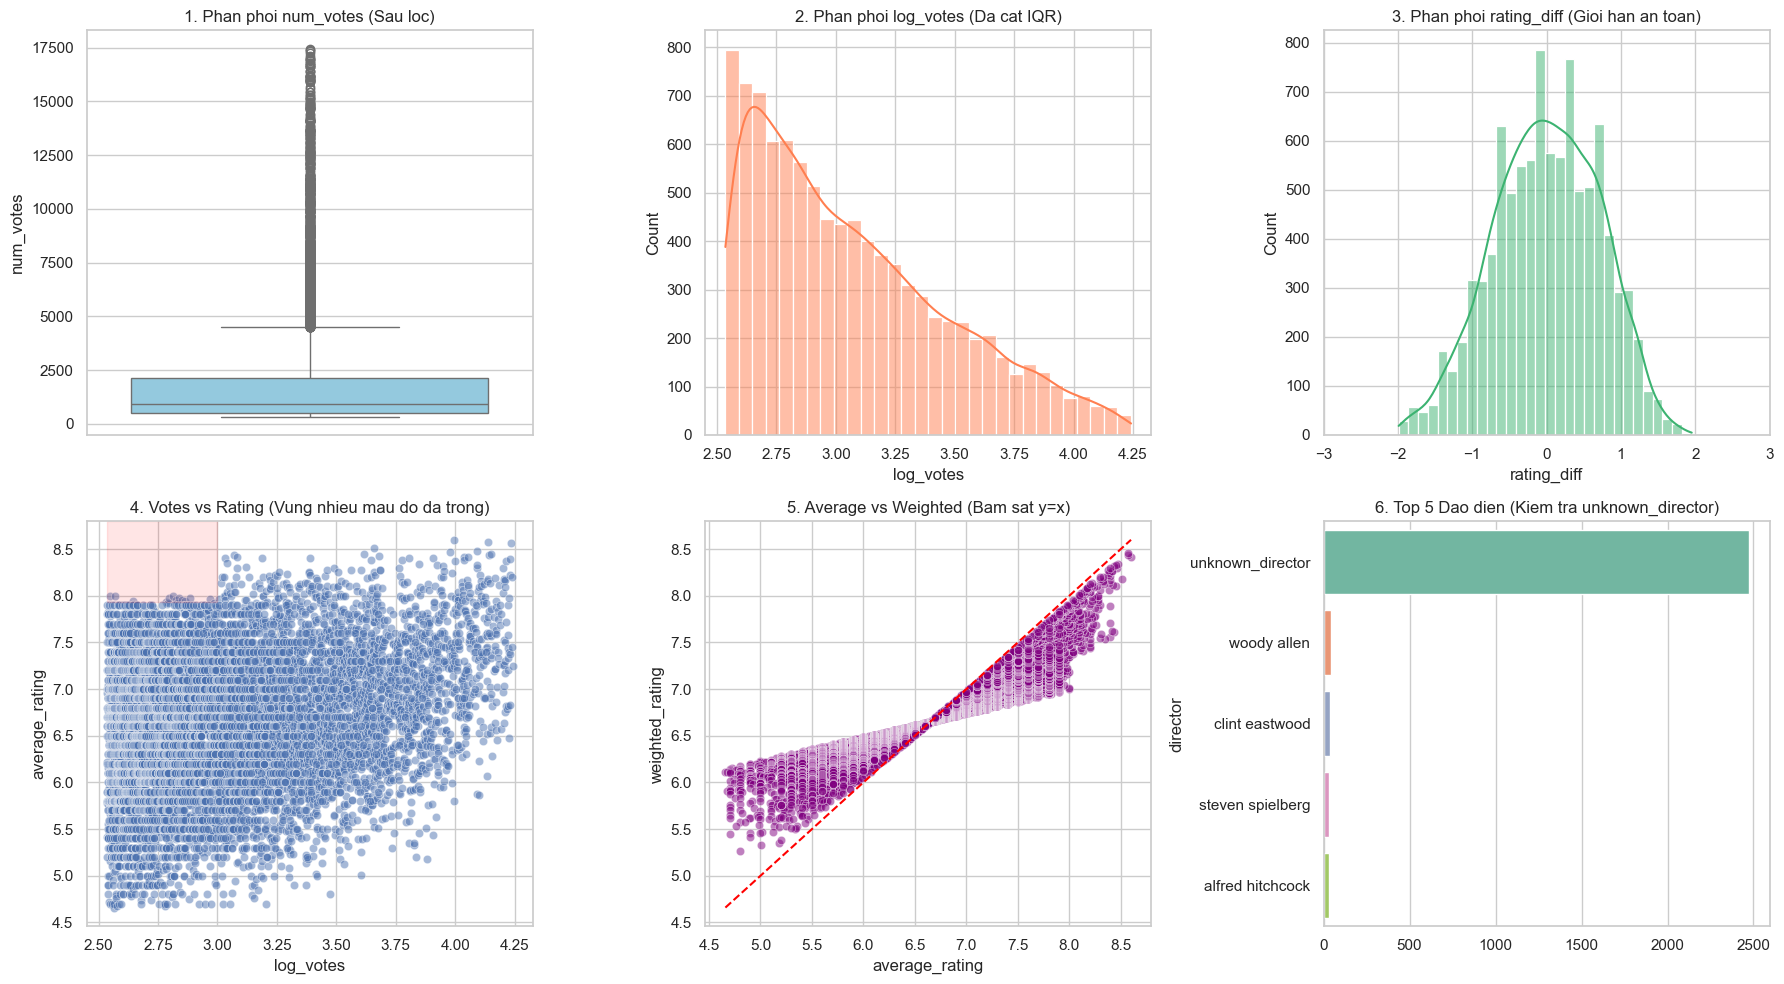

Kiem tra hoan tat. Neu cac bieu do dat chuan, tien hanh xuat file CSV.


In [16]:
#-----------------------------------------------------------
#-----------------------Visual QA---------------------------
#-----------------------------------------------------------

print("-"*60)
print("FINAL VISUAL QA")
print("-"*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.set_theme(style="whitegrid")

#1. Boxplot num_votes: Kiem tra do lech phai sau khi loc
sns.boxplot(y=df_cp['num_votes'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Phan phoi num_votes (Sau loc)')

#2. Histogram log_votes: Kiem tra su phan bo da cat bo hai duoi IQR
sns.histplot(df_cp['log_votes'], kde=True, ax=axes[0, 1], color='coral', bins=30)
axes[0, 1].set_title('2. Phan phoi log_votes (Da cat IQR)')

#3. Histogram rating_diff: Kiem tra nguong ngat cung [-2, 2]
sns.histplot(df_cp['rating_diff'], kde=True, ax=axes[0, 2], color='mediumseagreen', bins=30)
axes[0, 2].set_xlim(-3, 3) 
axes[0, 2].set_title('3. Phan phoi rating_diff (Gioi han an toan)')

#4. Scatter log_votes vs average_rating: Kiem tra vung nhieu ngu canh
sns.scatterplot(data=df_cp, x='log_votes', y='average_rating', alpha=0.5, ax=axes[1, 0])
axes[1, 0].axvspan(xmin=df_cp['log_votes'].min(), xmax=3.0, ymin=0.8, ymax=1.0, color='red', alpha=0.1)
axes[1, 0].set_title('4. Votes vs Rating (Vung nhieu mau do da trong)')

#5. Scatter average_rating vs weighted_rating: Kiem tra tinh nhat quan
sns.scatterplot(data=df_cp, x='average_rating', y='weighted_rating', alpha=0.5, ax=axes[1, 1], color='purple')
min_val = min(df_cp['average_rating'].min(), df_cp['weighted_rating'].min())
max_val = max(df_cp['average_rating'].max(), df_cp['weighted_rating'].max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
axes[1, 1].set_title('5. Average vs Weighted (Bam sat y=x)')

#6. Barplot Dao dien: Kiem tra viec gom nhom thuc te hiem
top_directors = df_cp['director'].value_counts().head(5)
sns.barplot(x=top_directors.values, y=top_directors.index, ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('6. Top 5 Dao dien (Kiem tra unknown_director)')

plt.tight_layout()
plt.show()

print("Kiem tra hoan tat. Neu cac bieu do dat chuan, tien hanh xuat file CSV.")

In [ ]:
cleaned_shape = df_cp.shape[0]
original_shape = df.shape[0]
cleaned_shape = df_cp.shape[0]
removed_count = original_shape - cleaned_shape
retention_rate = (cleaned_shape / original_shape) * 100

print("-"*60)
print("KET QUA EDA VA LAM SACH DU LIEU")
print("-"*60)
print(f"So luong phim ban dau      : {original_shape}")
print(f"So luong phim giu lai      : {cleaned_shape}")
print(f"So luong Outliers bi xoa   : {removed_count}")
print(f"Ty le giu lai du lieu      : {retention_rate:.2f}%\n")

#Luu file csv ban sach
save_path = 'eda_preprocessed_outliers_removed.csv'
df_cp.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"Hoan tat! File da luu tai: {save_path}")
print("San sang chuyen sang Feature Engineering.")

------------------------------------------------------------
KET QUA EDA VA LAM SACH DU LIEU
------------------------------------------------------------
So luong phim ban dau      : 9993
So luong phim giu lai      : 9666
So luong Outliers bi xoa   : 327
Ty le giu lai du lieu      : 96.73%

Hoan tat! File da luu tai: eda_preprocessed_outliers_removed.csv
San sang chuyen sang Feature Engineering.
